In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import json
from typing import List, Dict, Tuple
from pg_interactor import Postgres
import numpy as np
import warnings
import time
import scipy.stats as stats
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [34]:
class PlanRankingDataset(Dataset):
    # 线性映射到[0,1]区间（也可用sigmoid增强非线性）
    def advantage_to_label(self, advantage):
        # 限制优势范围在[-1,1]（避免极端值影响）
        advantage_clamped = max(-1.0, min(1.0, advantage))
        # 映射到[0,1]：advantage=-1 → 0，advantage=0 → 0.5，advantage=1 → 1.0
        return (advantage_clamped + 1.0) / 2.0
    
    def __init__(self, query_groups: List[Dict]):
        self.pairs = []
        
        for group in query_groups:
            embeddings = group['embeddings']
            latencies = group['latencies']
            n_plans = len(latencies)
            
            for i in range(n_plans):
                for j in range(i + 1, n_plans):
                    # 计算i相对于j的时延优势（相对差异）
                    # 避免除0：若两者时延都为0，视为相等
                    sum_latency = latencies[i] + latencies[j]
                    if sum_latency < 1e-8:
                        relative_advantage = 0.0
                    else:
                        relative_advantage = (latencies[j] - latencies[i]) / sum_latency
                    
                    # 将优势转化为[0,1]标签
                    label = self.advantage_to_label(relative_advantage)
                    
                    self.pairs.append({
                        'embedding_i': embeddings[i],
                        'embedding_j': embeddings[j],
                        'label': label,  # 标签反映差异程度
                        'query_name': group['query_name'],
                    })
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        pair = self.pairs[idx]
        emb_i = json.loads(pair['embedding_i']) if isinstance(pair['embedding_i'], str) else pair['embedding_i']
        emb_j = json.loads(pair['embedding_j']) if isinstance(pair['embedding_j'], str) else pair['embedding_j']
        
        return (
            torch.FloatTensor(emb_i),
            torch.FloatTensor(emb_j),
            torch.FloatTensor([pair['label']]),
        )

In [35]:
class PlanRankingModelV1(nn.Module):
    def __init__(self, input_dim=128, hidden_dims=[256, 128, 64]):
        """
        计划排序模型
        
        Args:
            input_dim: 输入维度 (embedding维度)
            hidden_dims: 隐藏层维度列表
        """
        super(PlanRankingModelV1, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            prev_dim = hidden_dim
        
        # 输出单个分数
        layers.append(nn.Linear(prev_dim, 1))
        
        self.score_network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.score_network(x)
    

class PlanRankingModelV2(nn.Module):
    def __init__(self, input_dim=128, hidden_dims=[512, 384, 256, 128, 64]):  # 改动1：层数从3→5，维度增大
        super(PlanRankingModelV2, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.1)  # 改动2：降低Dropout（过浅模型用高Dropout会削弱学习能力）
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.score_network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.score_network(x)
    

class PlanRankingModelV3(nn.Module):
    def __init__(self, input_dim=128, hidden_dims=[384, 256, 128, 64]):
        super(PlanRankingModelV3, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),  # 改动1：加入批归一化（稳定训练）
                nn.LeakyReLU(0.1),  # 改动2：用LeakyReLU替代ReLU（避免神经元死亡）
                nn.Dropout(0.15)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.score_network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.score_network(x)
    

class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        # 主路径：线性层 + 批归一化 + 激活
        self.main_path = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1)
        )
        # 残差路径：如果维度不同，用1x1线性层调整；否则直接返回
        self.residual_path = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
    
    def forward(self, x):
        residual = self.residual_path(x)  # 调整残差维度（如需）
        x = self.main_path(x)             # 主路径计算
        return x + residual               # 残差相加（维度已匹配）
    
class PlanRankingModelV4(nn.Module):
    def __init__(self, input_dim=128, hidden_dims=[256, 256, 128, 128, 64, 64]):
        super(PlanRankingModelV4, self).__init__()
        
        # 初始层：将输入维度映射到第一个隐藏层维度
        self.initial = nn.Linear(input_dim, hidden_dims[0])
        
        # 构建残差块序列（每个块处理一次维度过渡）
        self.residual_blocks = nn.ModuleList()
        # 从第一个隐藏层开始，依次连接到下一个隐藏层
        for i in range(len(hidden_dims) - 1):
            in_dim = hidden_dims[i]
            out_dim = hidden_dims[i + 1]
            self.residual_blocks.append(ResidualBlock(in_dim, out_dim))
        
        # 输出层：从最后一个隐藏层维度映射到1（分数）
        self.final = nn.Linear(hidden_dims[-1], 1)
    
    def forward(self, x):
        # 初始映射：输入维度 → 第一个隐藏层维度
        x = self.initial(x)
        
        # 依次通过每个残差块（维度自动匹配）
        for block in self.residual_blocks:
            x = block(x)
        
        # 输出分数
        return self.final(x)


class AttentionLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # 学习每个维度的权重（输出维度与输入dim一致）
        self.attention = nn.Sequential(
            nn.Linear(dim, dim),  # 直接映射到与输入相同的维度
            nn.ReLU(),
            nn.Linear(dim, dim),  # 输出每个维度的权重分数
            nn.Softmax(dim=1)  # 在维度dim=1上做softmax，确保权重和为1
        )
    
    def forward(self, x):
        # x: (batch_size, dim) → 计算每个维度的注意力权重
        attn_weights = self.attention(x)  # (batch_size, dim)，每个维度的权重
        return x * attn_weights  # 按维度加权（(batch_size, dim) * (batch_size, dim)）


class PlanRankingModelV5(nn.Module):
    def __init__(self, input_dim=128, hidden_dims=[256, 128, 64]):
        super(PlanRankingModelV5, self).__init__()
        
        # 注意力层（关注embedding关键维度）
        self.attention = AttentionLayer(input_dim)
        
        # 主体网络
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.1),
                nn.Dropout(0.1)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.score_network = nn.Sequential(*layers)
    
    def forward(self, x):
        # x: (batch_size, input_dim)
        x = self.attention(x)  # 注意力加权后仍为 (batch_size, input_dim)
        return self.score_network(x)


In [36]:
class ListwiseRankingModel(nn.Module):
    def __init__(self, input_dim=128, hidden_dims=[256, 128, 64]):
        """
        列表式排序模型，直接处理整个计划列表
        
        Args:
            input_dim: 输入维度
            hidden_dims: 隐藏层维度列表
        """
        super(ListwiseRankingModel, self).__init__()
        
        # 共享的编码网络
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            prev_dim = hidden_dim
        
        self.encoder = nn.Sequential(*layers)
        
        # 注意力机制用于聚合整个列表信息
        self.attention = nn.MultiheadAttention(
            embed_dim=prev_dim, 
            num_heads=4,
            batch_first=True
        )
        
        # 最终评分层
        self.scorer = nn.Linear(prev_dim, 1)
    
    def forward(self, plan_embeddings):
        """
        Args:
            plan_embeddings: [batch_size, list_size, embedding_dim]
        """
        batch_size, list_size, _ = plan_embeddings.shape
        
        # 编码每个计划
        encoded_plans = self.encoder(plan_embeddings.view(-1, plan_embeddings.size(-1)))
        encoded_plans = encoded_plans.view(batch_size, list_size, -1)
        
        # 使用注意力机制考虑计划间的关系
        attended_plans, _ = self.attention(
            encoded_plans, encoded_plans, encoded_plans
        )
        
        # 计算每个计划的分数
        scores = self.scorer(attended_plans).squeeze(-1)
        
        return scores

In [37]:
def load_data_from_db(db_config):
    """从数据库加载数据并按查询名分组"""
    pg = Postgres()

    pg.setup(
        dbname=db_config["dbname"],
        host=db_config["host"],
        user=db_config["user"],
        password=db_config["password"],
        port=db_config["port"]
    )
    
    # 查询所有数据
    rows = pg.execute("""
        SELECT name, embedding, latency_s, id, plan, strategy 
        FROM public.plan_explored 
        WHERE embedding IS NOT NULL AND latency_s IS NOT NULL
        ORDER BY name, latency_s
    """,fetch=True)
    
    # 按查询名分组
    query_groups = {}
    for name, embedding, latency, plan_id, plan_json, strategy_json in rows:
        if name not in query_groups:
            query_groups[name] = {
                'plans': [],
                'embeddings': [],
                'latencies': [],
                'plan_ids': [],
                'plan_jsons': [],
                'strategy_jsons': []
            }
        
        query_groups[name]['plans'].append({
            'id': plan_id,
            'embedding': embedding,
            'latency': float(latency),
            'plan_json': plan_json,
            'strategy_json': strategy_json
        })
        query_groups[name]['embeddings'].append(embedding)
        query_groups[name]['latencies'].append(float(latency))
        query_groups[name]['plan_ids'].append(plan_id)
        query_groups[name]['plan_jsons'].append(plan_json)
        query_groups[name]['strategy_jsons'].append(strategy_json)
    
    # 转换为列表格式
    grouped_data = []
    for name, group in query_groups.items():
        if len(group['plans']) >= 2:  # 只保留有至少2个计划的查询
            grouped_data.append({
                'query_name': name,
                'plans': group['plans'],
                'embeddings': group['embeddings'],
                'latencies': group['latencies'],
                'plan_ids': group['plan_ids']
            })
    
    return grouped_data


def pairwise_ranking_loss(score_i, score_j, labels, margin=1.0):
    """
    适配连续标签的成对排序损失函数（考虑差异程度）
    
    Args:
        score_i (Tensor): 计划i的分数，形状为[N]
        score_j (Tensor): 计划j的分数，形状为[N]
        labels (Tensor): 连续标签（0~1），值越大表示i相对j越好
        margin (float): 最大边界值（控制差异的强度）
    """
    if margin < 0:
        raise ValueError("margin必须≥0")
    if score_i.shape != score_j.shape or score_i.shape != labels.shape:
        raise ValueError("输入形状必须一致")
    
    score_diff = score_i - score_j  # 实际分数差（i-j）
    
    # 1. 基于标签设定“目标分数差”
    # label=1 → 目标：score_i - score_j = margin（i显著优于j）
    # label=0.5 → 目标：score_i - score_j = 0（两者接近）
    # label=0 → 目标：score_i - score_j = -margin（i显著差于j）
    target_diff = 2 * (labels - 0.5) * margin  # 映射标签到[-margin, margin]
    
    # 2. 计算“实际差异与目标差异的偏离”
    # 若实际差异 ≥ 目标差异 → 满足要求，损失为0
    # 若实际差异 < 目标差异 → 损失为两者的差距（需要拉大差异）
    loss = torch.clamp(target_diff - score_diff, min=0)
    
    return loss.mean()


def listwise_ranking_loss(predicted_scores, true_rankings, method='listnet'):
    """
    列表式排序损失函数
    
    Args:
        predicted_scores: 模型预测的分数 [batch_size, list_size]
        true_rankings: 真实排名 [batch_size, list_size] (值越小排名越靠前)
        method: 损失方法 ('listnet', 'listmle', 'softmax_cross_entropy')
    """
    if method == 'listnet':
        # ListNet损失：使用top-one概率的交叉熵
        pred_probs = torch.softmax(predicted_scores, dim=-1)
        true_probs = torch.softmax(-true_rankings, dim=-1)  # 排名越靠前，概率越高
        
        loss = -torch.sum(true_probs * torch.log(pred_probs + 1e-8), dim=-1)
    
    elif method == 'listmle':
        # ListMLE损失：负对数似然
        _, indices = torch.sort(true_rankings, dim=-1)
        sorted_scores = torch.gather(predicted_scores, 1, indices)
        
        # 计算每个位置的累积和
        cum_max = torch.cumsum(sorted_scores.exp(), dim=-1)
        loss = -sorted_scores + torch.log(cum_max + 1e-8)
        loss = loss.mean(dim=-1)
    
    else:  # softmax_cross_entropy
        # 将真实排名转换为概率分布
        true_probs = torch.softmax(-true_rankings, dim=-1)
        pred_probs = torch.softmax(predicted_scores, dim=-1)
        loss = torch.nn.functional.cross_entropy(
            predicted_scores, true_probs.argmax(dim=-1)
        )
        return loss
    
    return loss.mean()


def create_listwise_dataloader(query_groups, batch_size=32):
    """为列表式排序创建数据加载器"""
    plan_embeddings = []
    true_rankings = []
    
    for group in query_groups:
        embeddings = np.array(group['embeddings'])
        print(f"Group {group['query_name']} embeddings shape: {embeddings.shape}")  # 调试信息
        latencies = np.array(group['latencies'])
        
        # 根据时延计算真实排名（时延越小排名越靠前）
        ranks = np.argsort(np.argsort(latencies))
        
        plan_embeddings.append(embeddings)
        true_rankings.append(ranks)
    
    # 找到最大的计划数
    max_len = max(emb.shape[0] for emb in plan_embeddings)
    
    padded_embeddings = []
    padded_rankings = []
    
    for emb, rank in zip(plan_embeddings, true_rankings):
        pad_len = max_len - emb.shape[0]
        if pad_len > 0:
            # 确保 emb 是二维的: (n_plans, embedding_dim)
            padded_emb = np.pad(emb, ((0, pad_len), (0, 0)), mode='constant')
            padded_rank = np.pad(rank, (0, pad_len), mode='constant', constant_values=max_len)
        else:
            padded_emb = emb
            padded_rank = rank
        
        padded_embeddings.append(padded_emb)
        padded_rankings.append(padded_rank)
    
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(np.array(padded_embeddings)),
        torch.FloatTensor(np.array(padded_rankings))
    )
    
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def train_model(db_config, model_type='pairwise', epochs=100, batch_size=32):
    """训练排序模型"""
    
    start_time = time.time()
    # 加载数据
    print("加载数据...")
    query_groups = load_data_from_db(db_config)
    print(f"共加载 {len(query_groups)} 个查询组")
    
    # 分割训练集和测试集
    train_groups, test_groups = train_test_split(
        query_groups, test_size=0.2, random_state=42
    )
    
    if model_type == 'pairwise':
        # 成对排序方法
        train_dataset = PlanRankingDataset(train_groups)
        test_dataset = PlanRankingDataset(test_groups)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size)
        
        model = PlanRankingModelV5(input_dim=128)
        criterion = pairwise_ranking_loss
    
    else:  # listwise
        # 列表式排序方法需要特殊的数据处理
        train_loader = create_listwise_dataloader(train_groups, batch_size)
        test_loader = create_listwise_dataloader(test_groups, batch_size)
        
        model = ListwiseRankingModel(input_dim=128)
        criterion = lambda pred, true: listwise_ranking_loss(pred, true, method='listnet')
    
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    print(f"使用设备: {device}")
    print(f"训练样本数: {len(train_loader.dataset)}")
    print(f"测试样本数: {len(test_loader.dataset)}")
    
    # 训练循环
    best_loss = float('inf')
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        train_loss = 0.0
        
        for batch in train_loader:
            if model_type == 'pairwise':
                emb_i, emb_j, labels = batch
                emb_i, emb_j, labels = emb_i.to(device), emb_j.to(device), labels.to(device)
                
                optimizer.zero_grad()
                scores_i = model(emb_i)
                scores_j = model(emb_j)
                loss = criterion(scores_i, scores_j, labels)
            else:
                plan_embeddings, true_rankings = batch
                plan_embeddings, true_rankings = plan_embeddings.to(device), true_rankings.to(device)
                
                optimizer.zero_grad()
                pred_scores = model(plan_embeddings)
                loss = criterion(pred_scores, true_rankings)
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # 测试阶段
        model.eval()
        test_loss = 0.0
        
        with torch.no_grad():
            for batch in test_loader:
                if model_type == 'pairwise':
                    emb_i, emb_j, labels = batch
                    emb_i, emb_j, labels = emb_i.to(device), emb_j.to(device), labels.to(device)
                    
                    scores_i = model(emb_i)
                    scores_j = model(emb_j)
                    loss = criterion(scores_i, scores_j, labels)
                else:
                    plan_embeddings, true_rankings = batch
                    plan_embeddings, true_rankings = plan_embeddings.to(device), true_rankings.to(device)
                    
                    pred_scores = model(plan_embeddings)
                    loss = criterion(pred_scores, true_rankings)
                
                test_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        
        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')
        
        # 保存最佳模型
        if avg_test_loss < best_loss:
            best_loss = avg_test_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'loss': best_loss
            }, f'best_plan_ranking_model_{model_type}.pth')
        
        scheduler.step()

    print("训练完成!训练耗时:{:.2f}s".format(time.time() - start_time))
    return model, train_losses, test_losses


# 定义一个模型构造器字典
model_constructors = {
    'V1': lambda: PlanRankingModelV1(input_dim=128),
    'V2': lambda: PlanRankingModelV2(input_dim=128),
    'V3': lambda: PlanRankingModelV3(input_dim=128),
    'V4': lambda: PlanRankingModelV4(input_dim=128),
    'V5': lambda: PlanRankingModelV5(input_dim=128),
    'listwise': lambda: ListwiseRankingModel(input_dim=128)
}

def train_model_multi(db_config, ranking_type='pairwise', model_versions=['V1','V2','V3','V4','V5'],
                      epochs=100, batch_size=32):
    """
    同时训练并评估多种计划排序模型。
    
    Args:
        db_config: 数据库配置字典
        ranking_type: 排序方式，取值 'pairwise' 或 'listwise'
        model_versions: 要训练的模型版本列表，例如 ['V1','V2','V3','V4','V5']，或包含 'listwise'
        epochs: 训练周期
        batch_size: 批次大小
    Returns:
        results: dict, key为模型版本,value为 (model, train_losses, test_losses)
    """
    results = {}
    # 加载并分割数据，pairwise 与 listwise 数据构造方式不同
    print("加载数据...")
    query_groups = load_data_from_db(db_config)
    print(f"共加载 {len(query_groups)} 个查询组")
    train_groups, test_groups = train_test_split(query_groups, test_size=0.2, random_state=42)

    # 构造数据加载器
    if ranking_type == 'pairwise':
        train_dataset = PlanRankingDataset(train_groups)
        test_dataset = PlanRankingDataset(test_groups)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size)
        criterion = pairwise_ranking_loss
    else:
        # listwise 数据加载器
        train_loader = create_listwise_dataloader(train_groups, batch_size)
        test_loader = create_listwise_dataloader(test_groups, batch_size)
        criterion = lambda pred, true: listwise_ranking_loss(pred, true, method='listnet')
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")
    print(f"训练样本数: {len(train_loader.dataset)}")
    print(f"测试样本数: {len(test_loader.dataset)}")
    
    # 针对每个模型版本进行训练
    for version in model_versions:
        print(f"\n训练模型版本: {version}")
        # 构造模型
        model = model_constructors[version]()
        model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
        best_loss = float('inf')
        train_losses = []
        test_losses = []
        
        for epoch in range(epochs):
            ## 训练阶段
            model.train()
            train_loss = 0.0
            for batch in train_loader:
                optimizer.zero_grad()
                if ranking_type == 'pairwise':
                    emb_i, emb_j, labels = batch
                    emb_i, emb_j, labels = emb_i.to(device), emb_j.to(device), labels.to(device)
                    scores_i = model(emb_i)
                    scores_j = model(emb_j)
                    loss = criterion(scores_i, scores_j, labels)
                else:
                    plan_embeddings, true_rankings = batch
                    plan_embeddings, true_rankings = plan_embeddings.to(device), true_rankings.to(device)
                    pred_scores = model(plan_embeddings)
                    loss = criterion(pred_scores, true_rankings)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            ## 测试阶段
            model.eval()
            test_loss = 0.0
            with torch.no_grad():
                for batch in test_loader:
                    if ranking_type == 'pairwise':
                        emb_i, emb_j, labels = batch
                        emb_i, emb_j, labels = emb_i.to(device), emb_j.to(device), labels.to(device)
                        scores_i = model(emb_i)
                        scores_j = model(emb_j)
                        loss = criterion(scores_i, scores_j, labels)
                    else:
                        plan_embeddings, true_rankings = batch
                        plan_embeddings, true_rankings = plan_embeddings.to(device), true_rankings.to(device)
                        pred_scores = model(plan_embeddings)
                        loss = criterion(pred_scores, true_rankings)
                    test_loss += loss.item()
            avg_train_loss = train_loss / len(train_loader)
            avg_test_loss = test_loss / len(test_loader)
            train_losses.append(avg_train_loss)
            test_losses.append(avg_test_loss)
            print(f'Version {version} Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')
            
            # 保存最佳模型
            if avg_test_loss < best_loss:
                best_loss = avg_test_loss
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'epoch': epoch,
                    'loss': best_loss
                }, f'best_plan_ranking_model_{version}.pth')
            scheduler.step()
        results[version] = (model, train_losses, test_losses)
    
    print("所有模型训练完成!")
    return results

def predict_ranking(model, plan_embeddings, model_type='pairwise'):
    """预测计划的排序"""
    model.eval()
    
    if model_type == 'pairwise':
        # 成对排序：计算每个计划的分数
        scores = []
        with torch.no_grad():
            for embedding in plan_embeddings:
                embedding = json.loads(embedding) if isinstance(embedding, str) else embedding
                score = model(torch.FloatTensor(embedding).unsqueeze(0))
                scores.append(score.item())
        
        # 根据分数排序（分数越高排名越靠前）
        ranked_indices = np.argsort(scores)[::-1]
    
    else:
        # 列表式排序：直接处理整个列表
        with torch.no_grad():
            embeddings_tensor = torch.FloatTensor(np.array(plan_embeddings)).unsqueeze(0)
            scores = model(embeddings_tensor).squeeze(0).numpy()
            ranked_indices = np.argsort(scores)[::-1]
    
    return ranked_indices, scores

In [38]:

db_config={
        "dbname":"tpcds10",
        "host":"localhost",
        "user":"windy",
        "password":"",
        "port":5432
    }
    
# 训练成对排序模型
print("训练成对排序模型...")
results = train_model_multi(db_config, ranking_type='pairwise', model_versions=['V1','V2','V3','V4','V5'],
                                epochs=50, batch_size=32)

# # 训练列表式排序模型
# print("\n训练列表式排序模型...")
# listwise_model, train_losses2, test_losses2 = train_model(
#     db_config, model_type='listwise', epochs=50, batch_size=8
# )



训练成对排序模型...
加载数据...
共加载 97 个查询组
使用设备: cpu
训练样本数: 10540
测试样本数: 634

训练模型版本: V1
Version V1 Epoch 1/50, Train Loss: 0.2427, Test Loss: 0.4193
Version V1 Epoch 2/50, Train Loss: 0.2377, Test Loss: 0.4286
Version V1 Epoch 3/50, Train Loss: 0.2332, Test Loss: 0.4247
Version V1 Epoch 4/50, Train Loss: 0.2308, Test Loss: 0.4504
Version V1 Epoch 5/50, Train Loss: 0.2298, Test Loss: 0.4526
Version V1 Epoch 6/50, Train Loss: 0.2271, Test Loss: 0.4564
Version V1 Epoch 7/50, Train Loss: 0.2256, Test Loss: 0.4549
Version V1 Epoch 8/50, Train Loss: 0.2250, Test Loss: 0.4632
Version V1 Epoch 9/50, Train Loss: 0.2243, Test Loss: 0.4556
Version V1 Epoch 10/50, Train Loss: 0.2235, Test Loss: 0.4491
Version V1 Epoch 11/50, Train Loss: 0.2233, Test Loss: 0.4726
Version V1 Epoch 12/50, Train Loss: 0.2232, Test Loss: 0.4599
Version V1 Epoch 13/50, Train Loss: 0.2227, Test Loss: 0.4663
Version V1 Epoch 14/50, Train Loss: 0.2234, Test Loss: 0.4575
Version V1 Epoch 15/50, Train Loss: 0.2224, Test Loss: 0.4557
V

In [39]:
# 使用模型进行预测的示例
query_groups = load_data_from_db(db_config)

# 定义模型颜色
colors = {
    'V1': 'tab:blue',
    'V2': 'tab:orange',
    'V3': 'tab:green',
    'V4': 'tab:red',
    'V5': 'tab:purple'
}

# 初始化指标存储字典，对每个模型记录对应查询下的Spearman和实际排名
model_metrics = {version: {'spearman': [], 'actual_pos': [],'nice_choice':0} for version in results.keys()}
query_labels = []

for group in query_groups:
    if len(group['plan_ids']) <= 3:
        continue
    query_labels.append(group['query_name'])
    # 真实排名：时延越小排名越靠前
    actual_ranking = np.argsort(group['latencies'])
    for version, (model, _, _) in results.items():
        # 使用成对模型进行预测
        predicted_ranking, _ = predict_ranking(model, group['embeddings'], model_type='pairwise')
        # 计算Spearman相关系数
        spearman_corr, _ = stats.spearmanr(predicted_ranking, actual_ranking)
        model_metrics[version]['spearman'].append(spearman_corr)
        # 找出模型推荐的最好计划在候选计划中的实际排名（加1表示排名从1开始）
        best_pred_idx = predicted_ranking[0]
        actual_pos = np.where(actual_ranking == best_pred_idx)[0][0] + 1
        model_metrics[version]['actual_pos'].append(actual_pos)
        if actual_pos == 1:
            model_metrics[version]['nice_choice'] += 1


模型 V1 平均实际排名: 9.02
模型 V1 平均 Spearman 相关系数: 0.0726
模型 V1 推荐的最好计划实际排名为第1的次数: 4/63 (6.35%)
模型 V2 平均实际排名: 4.19
模型 V2 平均 Spearman 相关系数: 0.3228
模型 V2 推荐的最好计划实际排名为第1的次数: 26/63 (41.27%)
模型 V3 平均实际排名: 3.94
模型 V3 平均 Spearman 相关系数: 0.3052
模型 V3 推荐的最好计划实际排名为第1的次数: 22/63 (34.92%)
模型 V4 平均实际排名: 4.33
模型 V4 平均 Spearman 相关系数: 0.2379
模型 V4 推荐的最好计划实际排名为第1的次数: 26/63 (41.27%)
模型 V5 平均实际排名: 4.22
模型 V5 平均 Spearman 相关系数: 0.2783
模型 V5 推荐的最好计划实际排名为第1的次数: 22/63 (34.92%)


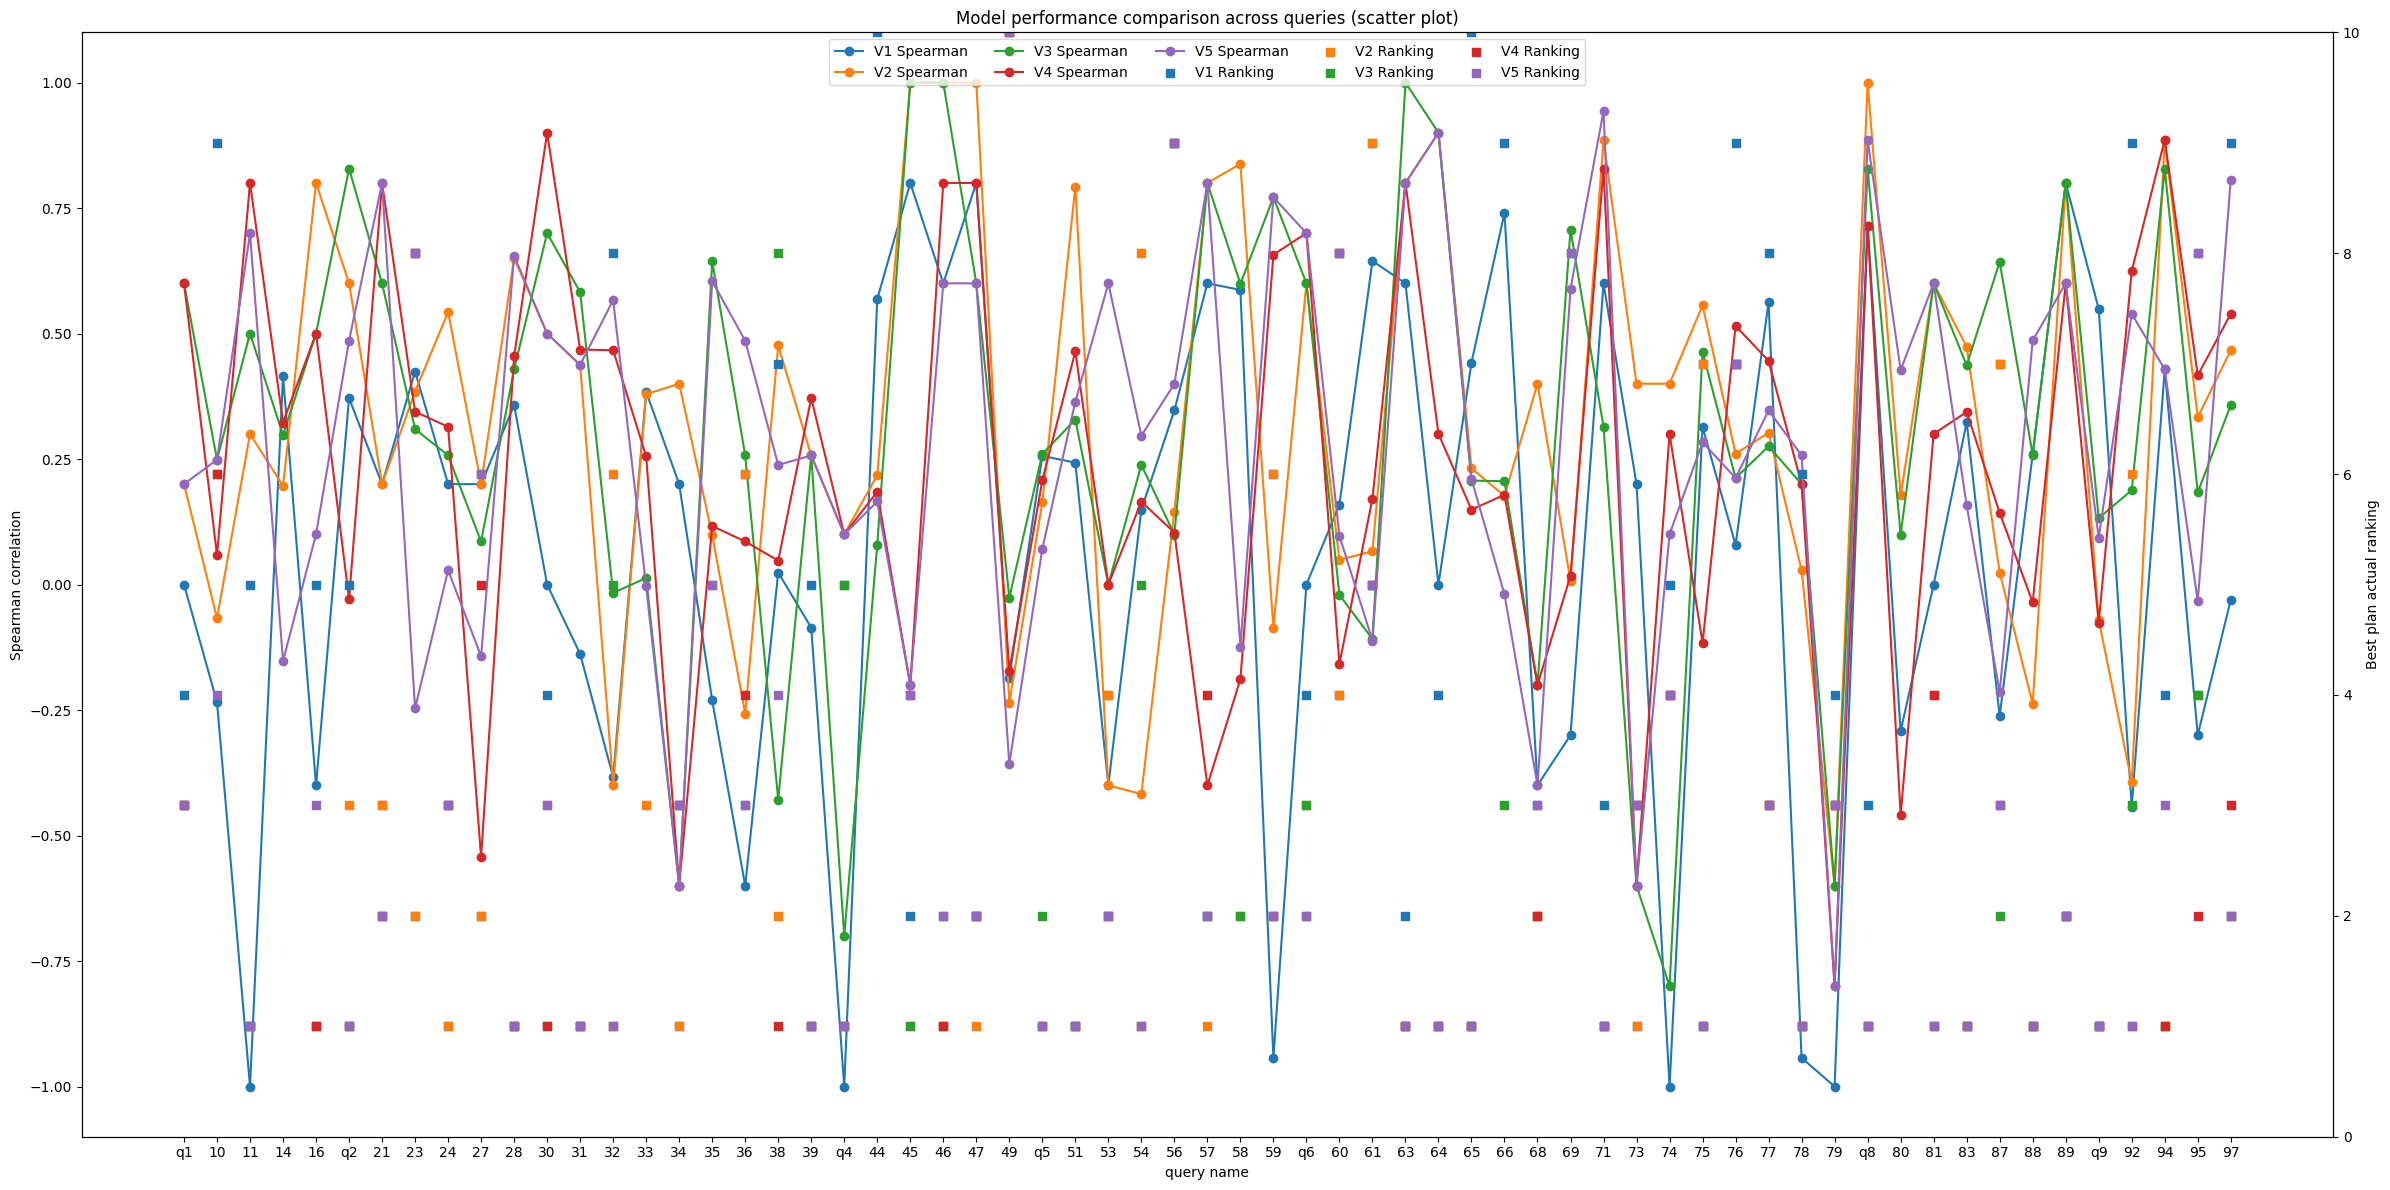

In [40]:
for version in results.keys():
    nice_count = model_metrics[version]['nice_choice']
    total_count = len(model_metrics[version]['actual_pos'])
    mean_spearman = np.mean(model_metrics[version]['spearman'])
    mean_ranking = np.mean(model_metrics[version]['actual_pos'])
    print(f"模型 {version} 平均实际排名: {mean_ranking:.2f}")
    print(f"模型 {version} 平均 Spearman 相关系数: {mean_spearman:.4f}")
    print(f"模型 {version} 推荐的最好计划实际排名为第1的次数: {nice_count}/{total_count} ({(nice_count/total_count)*100:.2f}%)")

short_labels = [label[-2:] for label in query_labels]
fig, ax1 = plt.subplots(figsize=(24, 12))
ax2 = ax1.twinx()

for version in results.keys():
    ax1.plot(short_labels, model_metrics[version]['spearman'], 
             color=colors[version],
             marker='o',
             label=f"{version} Spearman")
    ax2.scatter(short_labels, model_metrics[version]['actual_pos'], 
                color=colors[version],
                marker='s',
                label=f"{version} Ranking")

ax1.set_xlabel('query name')
ax1.set_ylabel('Spearman correlation')
ax2.set_ylabel('Best plan actual ranking')
plt.xticks(rotation=45)
plt.title("Model performance comparison across queries (scatter plot)")

# 限制右侧纵坐标范围为1到10
ax2.set_ylim(0, 10)

# 合并双轴图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', ncol=5)

fig.tight_layout()
plt.show()